In [ ]:
import os
import numpy as np
import rasterio
import xarray as xr

In [ ]:
xdata = xr.open_dataset('unprocessed_data/WEATHER/ST2020IA0004_Soybean.nc')
xdata['data'].isel(band=0, time=0).plot()

In [ ]:
with rasterio.open('unprocessed_data/yield_geotiffs/ST2019IA0007_Soybean.tif') as dataset:
    # Get the shape (height, width) and number of bands
    height, width = dataset.shape
    bands = dataset.count
    print(dataset.shape)

    

In [ ]:
np.load('unprocessed_data/S1GRD/ST2024IA0008_Soybean.tif',allow_pickle=True)

In [ ]:
test = np.load('unprocessed_data/WEATHER/ST2019IA0007_Soybean.npy')
test.shape

In [ ]:
root_dir = 'processed_data_monthly'
shapes = set()
dtypes = dict()  # dtype: sample file
dtype_folders = dict()  # dtype: set of subfolders

for subdir, dirs, files in os.walk(root_dir):
    for file in files:
        if file.endswith('.npy'):
            file_path = os.path.join(subdir, file)
            try:
                arr = np.load(file_path, mmap_mode='r')
                # Only keep the last two dimensions
                shape = arr.shape[-2:] if len(arr.shape) >= 2 else arr.shape
                shapes.add(shape)
                if arr.dtype not in dtypes:
                    dtypes[arr.dtype] = file_path
                # Track subfolders for each dtype
                dtype_folders.setdefault(arr.dtype, set()).add(os.path.relpath(subdir, root_dir))
            except Exception as e:
                print(f"Error loading {file_path}: {e}")

print("Unique (-1, -2) shapes in processed_data_monthly:")
for s in sorted(shapes):
    print(s)

print("\nUnique data types in processed_data_monthly (with a sample file):")
for dtype, sample_file in dtypes.items():
    print(f"{dtype}: {sample_file}")

print("\nSubfolders containing each unique dtype:")
for dtype, folders in dtype_folders.items():
    print(f"{dtype}:")
    for folder in sorted(folders):
        print(f"  {folder}")

In [ ]:
root_dir = 'processed_data_monthly'
target_folders = ['MODIS', 'S2L2A']

for folder in target_folders:
    folder_path = os.path.join(root_dir, folder)
    if not os.path.isdir(folder_path):
        print(f"Folder not found: {folder_path}")
        continue
    for file in os.listdir(folder_path):
        if file.endswith('.npy'):
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                if arr.dtype != np.float32:
                    arr = arr.astype(np.float32)
                    np.save(file_path, arr)
                    print(f"Converted and saved: {file_path}")
            except Exception as e:
                print(f"Error processing {file_path}: {e}")

In [ ]:
test = np.load('processed_data_monthly/S2L2A/ST2019IA0007_Soybean.npy')
test.shape

In [ ]:
root_dir = './data_download/S1/final_s1'
cnt = 0
"""
Walk through subfolders, read GeoTIFF files, and print their shapes.

Args:
    root_dir (str): Path to the root directory containing GeoTIFF files.
"""
# Walk through all subfolders and files in the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        # Check if the file is a GeoTIFF (.tif or .tiff, case-insensitive)
        if file.lower().endswith(('.tif', '.tiff')):
            file_path = os.path.join(root, file)
            try:
                # Open the GeoTIFF file using rasterio
                with rasterio.open(file_path) as dataset:
                    # Get the shape (height, width) and number of bands
                    height, width = dataset.shape
                    bands = dataset.count
                    print(f"File: {file_path}")
                    print(f"Shape: (height={height}, width={width}, bands={bands})")
                    print("-" * 50)
            except rasterio.errors.RasterioIOError as e:
                print(f"Error reading {file_path}: {e}")
            except Exception as e:
                print(f"Unexpected error with {file_path}: {e}")

In [ ]:
root_dir = './unprocessed_data/yield_geotiffs'
cnt = 0
"""
Walk through subfolders, read GeoTIFF files, and print their shapes.

Args:
    root_dir (str): Path to the root directory containing GeoTIFF files.
"""
# Walk through all subfolders and files in the root directory
for root, dirs, files in os.walk(root_dir):
    for file in files:
        # Check if the file is a GeoTIFF (.tif or .tiff, case-insensitive)
        if file.lower().endswith(('.tif', '.tiff')):
            file_path = os.path.join(root, file)
            try:
                # Open the GeoTIFF file using rasterio
                with rasterio.open(file_path) as dataset:
                    # Get the shape (height, width) and number of bands
                    height, width = dataset.shape
                    bands = dataset.count
                    print(f"File: {file_path}")
                    print(f"Shape: (height={height}, width={width}, bands={bands})")
                    print("-" * 50)
            except rasterio.errors.RasterioIOError as e:
                print(f"Error reading {file_path}: {e}")
            except Exception as e:
                print(f"Unexpected error with {file_path}: {e}")

In [ ]:
batch['image']['S2L2A'].shape

In [ ]:
import geopandas as gpd

In [ ]:
gpd.read_parquet('Yield_2024.parquet')

In [ ]:
import os

folder_path = 'processed_data_biweekly_1/S1GRD'

soybean_count = 0
corn_count = 0

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            if 'soybean' in file.lower():
                soybean_count += 1
            if 'corn' in file.lower():
                corn_count += 1
    
    print(f"Number of Soybean files: {soybean_count}")
    print(f"Number of Corn files: {corn_count}")
else:
    print(f"Folder not found: {folder_path}")

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re

folder_path = 'processed_data_biweekly_12/S1GRD'

# Dictionary to store counts: {year: {crop: [counts of all-zero time steps per file]}}
data_by_year_crop = {}

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            # Extract year and crop from filename using regex
            match = re.match(r'ST(\d{4}).*_(Corn|Soybean)\.npy', file, re.IGNORECASE)
            if not match:
                print(f"Filename doesn't match expected pattern: {file}")
                continue
            
            year = match.group(1)
            crop = match.group(2).capitalize()
            
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                # arr.shape is (N, C, H, W) where N=12
                N, C, H, W = arr.shape
                
                # Count how many time steps are fully zero
                all_zero_count = 0
                for n in range(N):
                    if np.all(arr[n, :, :, :] == 0):
                        all_zero_count += 1
                
                # Store the count
                if year not in data_by_year_crop:
                    data_by_year_crop[year] = {}
                if crop not in data_by_year_crop[year]:
                    data_by_year_crop[year][crop] = []
                
                data_by_year_crop[year][crop].append(all_zero_count)
                    
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
    
    # Create visualizations
    years = sorted(data_by_year_crop.keys())
    crops = ['Corn', 'Soybean']
    
    # Plot 1: Distribution by year and crop
    fig, axes = plt.subplots(len(years), 2, figsize=(14, 4*len(years)))
    if len(years) == 1:
        axes = axes.reshape(1, -1)
    
    for i, year in enumerate(years):
        for j, crop in enumerate(crops):
            ax = axes[i, j]
            if crop in data_by_year_crop[year]:
                counts = data_by_year_crop[year][crop]
                ax.hist(counts, bins=range(0, 14), edgecolor='black', alpha=0.7, align='left')
                ax.set_xlabel('Number of All-Zero Time Steps (out of 12)')
                ax.set_ylabel('Frequency')
                ax.set_title(f'{year} - {crop} (n={len(counts)} files)')
                ax.set_xticks(range(0, 13))
                ax.grid(True, alpha=0.3)
                
                # Add statistics
                mean_zeros = np.mean(counts)
                median_zeros = np.median(counts)
                ax.axvline(mean_zeros, color='r', linestyle='--', label=f'Mean: {mean_zeros:.2f}')
                ax.axvline(median_zeros, color='g', linestyle='--', label=f'Median: {median_zeros:.2f}')
                ax.legend()
            else:
                ax.text(0.5, 0.5, f'No {crop} data for {year}', 
                       ha='center', va='center', transform=ax.transAxes)
                ax.set_xlabel('Number of All-Zero Time Steps (out of 12)')
                ax.set_ylabel('Frequency')
                ax.set_title(f'{year} - {crop}')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)
    for year in years:
        print(f"\nYear: {year}")
        for crop in crops:
            if crop in data_by_year_crop[year]:
                counts = data_by_year_crop[year][crop]
                print(f"  {crop}:")
                print(f"    Total files: {len(counts)}")
                print(f"    Mean all-zero time steps: {np.mean(counts):.2f}")
                print(f"    Median all-zero time steps: {np.median(counts):.2f}")
                print(f"    Min: {np.min(counts)}, Max: {np.max(counts)}")
                print(f"    Files with 0 all-zero time steps: {np.sum(np.array(counts) == 0)}")
                print(f"    Files with 12 all-zero time steps: {np.sum(np.array(counts) == 12)}")
            else:
                print(f"  {crop}: No data")
    
else:
    print(f"Folder not found: {folder_path}")

/tmp/ipykernel_3408087/1931810514.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


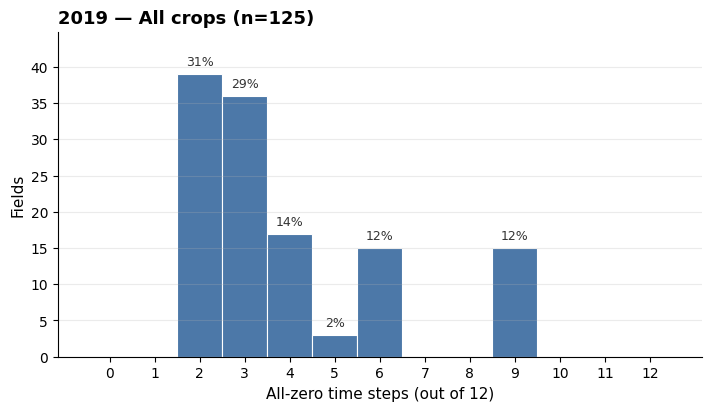

/tmp/ipykernel_3408087/1931810514.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


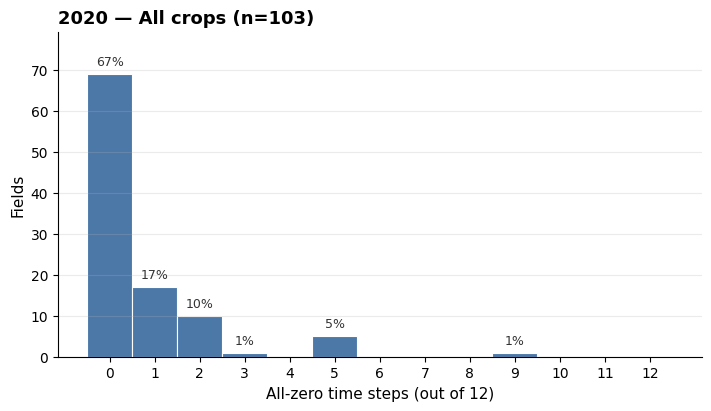

/tmp/ipykernel_3408087/1931810514.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


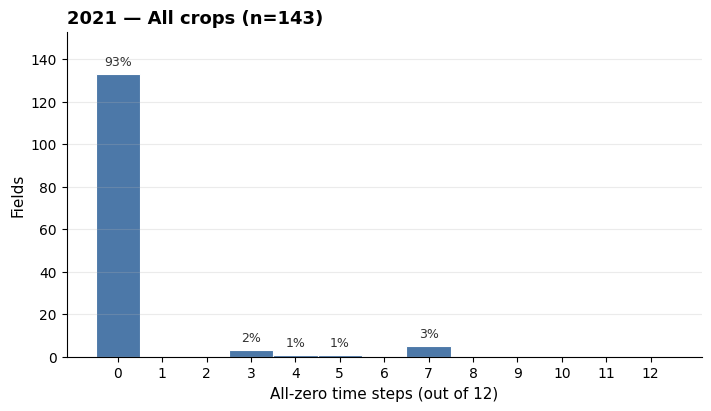

/tmp/ipykernel_3408087/1931810514.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


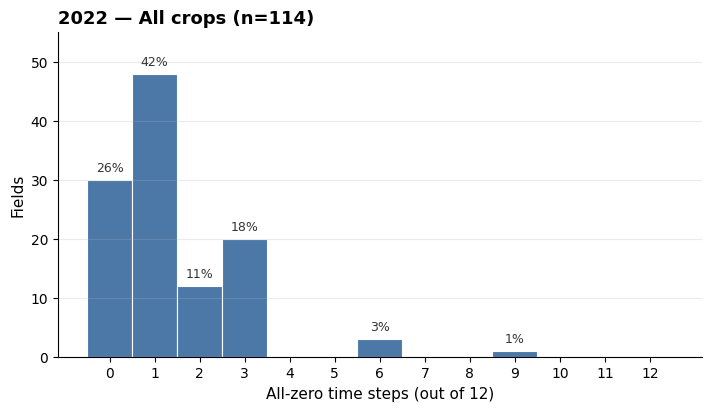

/tmp/ipykernel_3408087/1931810514.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


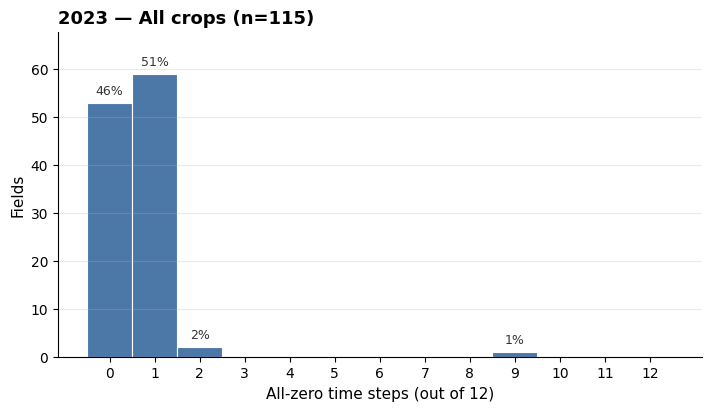


SUMMARY STATISTICS BY YEAR

Year: 2019
  Total files: 125
  Mean all-zero time steps: 3.95
  Median all-zero time steps: 3.00
  Min: 2, Max: 9
  Files with 0 all-zero time steps: 0
  Files with 12 all-zero time steps: 0

Year: 2020
  Total files: 103
  Mean all-zero time steps: 0.72
  Median all-zero time steps: 0.00
  Min: 0, Max: 9
  Files with 0 all-zero time steps: 69
  Files with 12 all-zero time steps: 0

Year: 2021
  Total files: 143
  Mean all-zero time steps: 0.37
  Median all-zero time steps: 0.00
  Min: 0, Max: 7
  Files with 0 all-zero time steps: 133
  Files with 12 all-zero time steps: 0

Year: 2022
  Total files: 114
  Mean all-zero time steps: 1.39
  Median all-zero time steps: 1.00
  Min: 0, Max: 9
  Files with 0 all-zero time steps: 30
  Files with 12 all-zero time steps: 0

Year: 2023
  Total files: 115
  Mean all-zero time steps: 0.63
  Median all-zero time steps: 1.00
  Min: 0, Max: 9
  Files with 0 all-zero time steps: 53
  Files with 12 all-zero time steps: 0


In [22]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib as mpl

folder_path = 'processed_data_biweekly_12/S1GRD'

# Publication-style defaults
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Dictionary to store counts: {year: [counts of all-zero time steps per file]}
data_by_year = {}

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            match = re.match(r'ST(\d{4}).*_(Corn|Soybean)\.npy', file, re.IGNORECASE)
            if not match:
                print(f"Filename doesn't match expected pattern: {file}")
                continue

            year = match.group(1)
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                # arr.shape is (N, C, H, W) where N=12
                N, C, H, W = arr.shape

                # Count how many time steps are fully zero
                all_zero_count = 0
                for n in range(N):
                    if np.all(arr[n, :, :, :] == 0):
                        all_zero_count += 1

                data_by_year.setdefault(year, []).append(all_zero_count)

            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    years = sorted(data_by_year.keys())
    if not years:
        print("No matching data found.")
    else:
        # Create output directory
        out_dir = "figures"
        os.makedirs(out_dir, exist_ok=True)
        
        # Integer-centered bins for 0..12 (inclusive)
        bins = np.arange(-0.5, 12.5 + 1, 1)

        # Plot each year separately
        for year in years:
            fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
            
            counts = data_by_year[year]
            n = len(counts)

            hist, edges, patches = ax.hist(
                counts, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.8
            )

            # Styling
            ax.set_title(f"{year} — All crops (n={n})", loc="left", fontweight="bold", fontsize=13)
            ax.set_xlabel("All-zero time steps (out of 12)")
            ax.set_ylabel("Fields")
            ax.set_xticks(np.arange(0, 13, 1))
            ax.grid(axis="y", alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Statistics lines
            mean_zeros = float(np.mean(counts)) if n else 0.0
            median_zeros = float(np.median(counts)) if n else 0.0
            # ax.axvline(mean_zeros, color="#E45756", linestyle="--", linewidth=1.5, label=f"Mean {mean_zeros:.2f}")
            # ax.axvline(median_zeros, color="#72B7B2", linestyle="--", linewidth=1.5, label=f"Median {median_zeros:.2f}")

            # Percentage annotations centered over bars
            total = n
            y_max = float(hist.max()) if hist.size else 0.0
            centers = 0.5 * (edges[:-1] + edges[1:])
            for h, x in zip(hist, centers):
                if h > 0 and total > 0:
                    ax.text(
                        x, h + max(0.1, y_max * 0.02),
                        f"{(h / total) * 100:.0f}%",
                        ha="center", va="bottom", fontsize=9, color="#333333"
                    )

            # Headroom
            ax.set_ylim(0, max(1, y_max * 1.15))

            ax.legend(frameon=False, loc="upper right", ncol=2)

            # Save each year's figure
            fig.savefig(os.path.join(out_dir, f"s1_missing_timesteps_{year}.png"), dpi=300, bbox_inches="tight")
            fig.savefig(os.path.join(out_dir, f"s1_missing_timesteps_{year}.pdf"), bbox_inches="tight")

            plt.show()
            plt.close(fig)

    # Summary statistics (unchanged)
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS BY YEAR")
    print("=" * 60)
    for year in years:
        counts = data_by_year[year]
        print(f"\nYear: {year}")
        print(f"  Total files: {len(counts)}")
        print(f"  Mean all-zero time steps: {np.mean(counts):.2f}")
        print(f"  Median all-zero time steps: {np.median(counts):.2f}")
        print(f"  Min: {np.min(counts)}, Max: {np.max(counts)}")
        print(f"  Files with 0 all-zero time steps: {np.sum(np.array(counts) == 0)}")
        print(f"  Files with 12 all-zero time steps: {np.sum(np.array(counts) == 12)}")
else:
    print(f"Folder not found: {folder_path}")

/tmp/ipykernel_3408087/3735937958.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


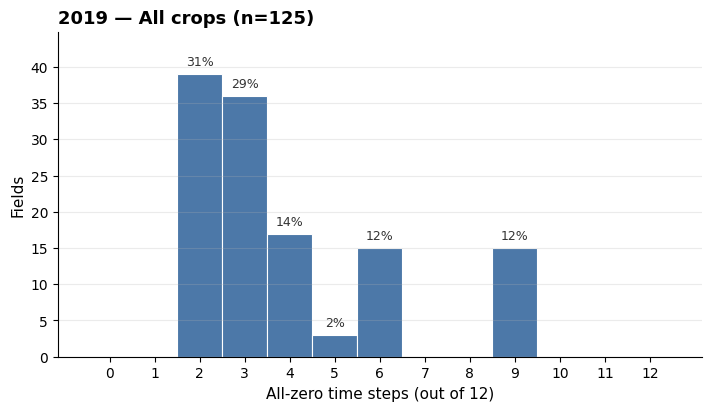

/tmp/ipykernel_3408087/3735937958.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


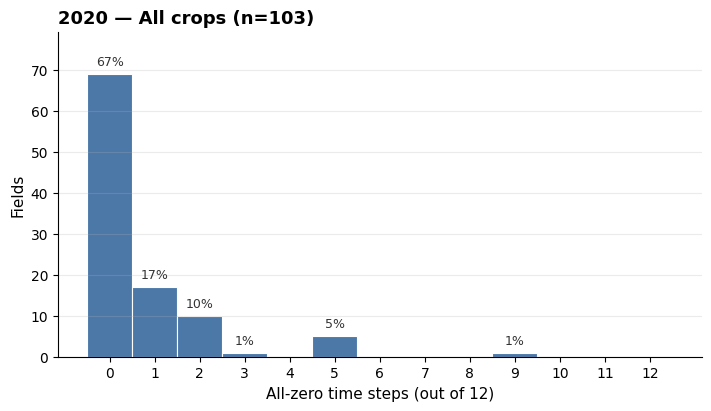

/tmp/ipykernel_3408087/3735937958.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


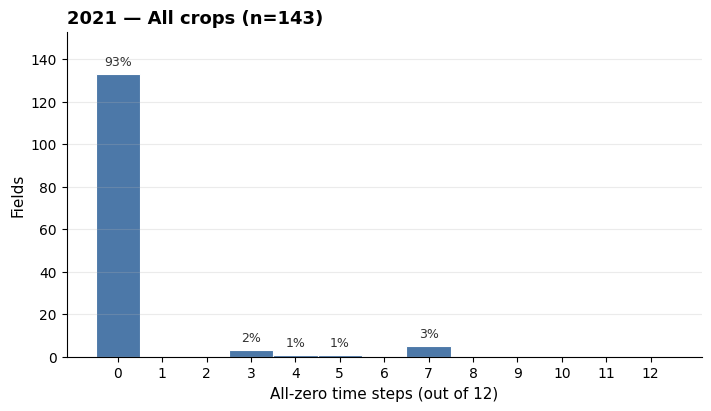

/tmp/ipykernel_3408087/3735937958.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


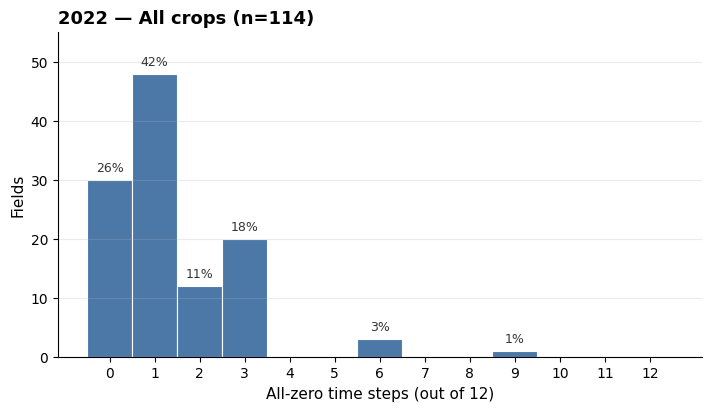

/tmp/ipykernel_3408087/3735937958.py:100: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, loc="upper right", ncol=2)


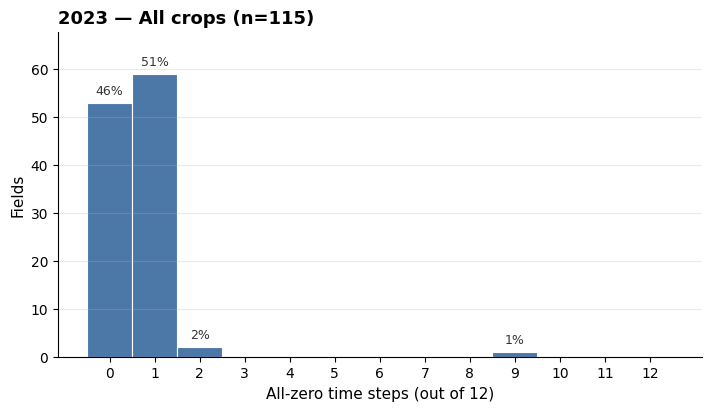


SUMMARY STATISTICS BY YEAR

Year: 2019
  Total files: 125
  Mean all-zero time steps: 3.95
  Median all-zero time steps: 3.00
  Min: 2, Max: 9
  Files with 0 all-zero time steps: 0
  Files with 12 all-zero time steps: 0

Year: 2020
  Total files: 103
  Mean all-zero time steps: 0.72
  Median all-zero time steps: 0.00
  Min: 0, Max: 9
  Files with 0 all-zero time steps: 69
  Files with 12 all-zero time steps: 0

Year: 2021
  Total files: 143
  Mean all-zero time steps: 0.37
  Median all-zero time steps: 0.00
  Min: 0, Max: 7
  Files with 0 all-zero time steps: 133
  Files with 12 all-zero time steps: 0

Year: 2022
  Total files: 114
  Mean all-zero time steps: 1.39
  Median all-zero time steps: 1.00
  Min: 0, Max: 9
  Files with 0 all-zero time steps: 30
  Files with 12 all-zero time steps: 0

Year: 2023
  Total files: 115
  Mean all-zero time steps: 0.63
  Median all-zero time steps: 1.00
  Min: 0, Max: 9
  Files with 0 all-zero time steps: 53
  Files with 12 all-zero time steps: 0


In [24]:
import os
import numpy as np
import matplotlib.pyplot as plt
import re
import matplotlib as mpl

folder_path = 'processed_data_biweekly_12/S2L2A'

# Publication-style defaults
mpl.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Dictionary to store counts: {year: [counts of all-zero time steps per file]}
data_by_year = {}

if os.path.isdir(folder_path):
    for file in os.listdir(folder_path):
        if file.lower().endswith('.npy'):
            match = re.match(r'ST(\d{4}).*_(Corn|Soybean)\.npy', file, re.IGNORECASE)
            if not match:
                print(f"Filename doesn't match expected pattern: {file}")
                continue

            year = match.group(1)
            file_path = os.path.join(folder_path, file)
            try:
                arr = np.load(file_path)
                # arr.shape is (N, C, H, W) where N=12
                N, C, H, W = arr.shape

                # Count how many time steps are fully zero
                all_zero_count = 0
                for n in range(N):
                    if np.all(arr[n, :, :, :] == 0):
                        all_zero_count += 1

                data_by_year.setdefault(year, []).append(all_zero_count)

            except Exception as e:
                print(f"Error loading {file_path}: {e}")

    years = sorted(data_by_year.keys())
    if not years:
        print("No matching data found.")
    else:
        # Create output directory
        out_dir = "figures"
        os.makedirs(out_dir, exist_ok=True)
        
        # Integer-centered bins for 0..12 (inclusive)
        bins = np.arange(-0.5, 12.5 + 1, 1)

        # Plot each year separately
        for year in years:
            fig, ax = plt.subplots(1, 1, figsize=(7, 4), constrained_layout=True)
            
            counts = data_by_year[year]
            n = len(counts)

            hist, edges, patches = ax.hist(
                counts, bins=bins, color="#4C78A8", edgecolor="white", linewidth=0.8
            )

            # Styling
            ax.set_title(f"{year} — All crops (n={n})", loc="left", fontweight="bold", fontsize=13)
            ax.set_xlabel("All-zero time steps (out of 12)")
            ax.set_ylabel("Fields")
            ax.set_xticks(np.arange(0, 13, 1))
            ax.grid(axis="y", alpha=0.25)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            # Statistics lines
            mean_zeros = float(np.mean(counts)) if n else 0.0
            median_zeros = float(np.median(counts)) if n else 0.0
            # ax.axvline(mean_zeros, color="#E45756", linestyle="--", linewidth=1.5, label=f"Mean {mean_zeros:.2f}")
            # ax.axvline(median_zeros, color="#72B7B2", linestyle="--", linewidth=1.5, label=f"Median {median_zeros:.2f}")

            # Percentage annotations centered over bars
            total = n
            y_max = float(hist.max()) if hist.size else 0.0
            centers = 0.5 * (edges[:-1] + edges[1:])
            for h, x in zip(hist, centers):
                if h > 0 and total > 0:
                    ax.text(
                        x, h + max(0.1, y_max * 0.02),
                        f"{(h / total) * 100:.0f}%",
                        ha="center", va="bottom", fontsize=9, color="#333333"
                    )

            # Headroom
            ax.set_ylim(0, max(1, y_max * 1.15))

            ax.legend(frameon=False, loc="upper right", ncol=2)

            # Save each year's figure
            fig.savefig(os.path.join(out_dir, f"s2_missing_timesteps_{year}.png"), dpi=300, bbox_inches="tight")
            fig.savefig(os.path.join(out_dir, f"s2_missing_timesteps_{year}.pdf"), bbox_inches="tight")

            plt.show()
            plt.close(fig)

    # Summary statistics (unchanged)
    print("\n" + "=" * 60)
    print("SUMMARY STATISTICS BY YEAR")
    print("=" * 60)
    for year in years:
        counts = data_by_year[year]
        print(f"\nYear: {year}")
        print(f"  Total files: {len(counts)}")
        print(f"  Mean all-zero time steps: {np.mean(counts):.2f}")
        print(f"  Median all-zero time steps: {np.median(counts):.2f}")
        print(f"  Min: {np.min(counts)}, Max: {np.max(counts)}")
        print(f"  Files with 0 all-zero time steps: {np.sum(np.array(counts) == 0)}")
        print(f"  Files with 12 all-zero time steps: {np.sum(np.array(counts) == 12)}")
else:
    print(f"Folder not found: {folder_path}")